In [2]:
pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 4.4 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 2.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 10.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# IR Assignment Groups 72

- Aditya Chittella

In [74]:
#Import required libraries
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import datetime
import urllib
import datetime
from bs4 import BeautifulSoup
from itertools import islice
from dateutil.relativedelta import relativedelta
from datetime import timedelta


### Task 1: Document Extraction from a search engine

In [75]:

class MSE(object):
    
    def __init__(self, number_of_results=None, l_from_date=None, l_to_date=None):
        
        assert isinstance(number_of_results, int), 'Number of results must be an integer'
        if number_of_results is None:
            self.number_of_results = 20
        else:
            self.number_of_results = number_of_results
        
        self.dt_format = '%d/%m/%Y'
        
        if l_to_date is None:
            self.to_date_obj = datetime.now()
        else:
            self.to_date_obj = datetime.datetime.strptime(l_to_date, self.dt_format)
            self.to_date_obj = datetime.datetime.combine(self.to_date_obj.date(), datetime.time(23, 59, 59))

        if l_from_date is None:
            five_days_ago = (datetime.datetime.now() - timedelta(days=5))
            self.from_date_obj = datetime.datetime.combine(five_days_ago.date(), datetime.time(0, 0, 0))
        else:
            self.from_date_obj = datetime.datetime.strptime(l_from_date, self.dt_format)

        self.search_engine = 'Google'
        print("Args: " + str(self.number_of_results) + ", " + str(self.from_date_obj) + ", " + str(self.to_date_obj))

    def parse_google_html(self,category,html):
        
        soup = BeautifulSoup(html, 'html.parser')
        found_result = []
        position_in_search_result = 1
        result_block = soup.find_all('div', attrs={'class': 'NiLAwe y6IFtc R7GTQ keNKEd j7vNaf nID9nc'})
        result_range = min(len(result_block), self.number_of_results)
        
        for result in result_block:

            link = result.find('a', attrs={'class': 'DY5T1d RZIKme'})
            #Extract the title
            title = result.find('h3', attrs={'class': 'ipQwMb ekueJc RD0gLb'})
            snippet = result.find('span', attrs={'class': 'xBbh9'})
            datetime_tag = result.find('time', attrs={'class': 'WW6dff uQIVzc Sksgp'})
            datetime_str = datetime_tag['datetime']
            datetime_obj = datetime.datetime.strptime(str(datetime_str), '%Y-%m-%dT%H:%M:%SZ')

            #if link and title:
            if self.from_date_obj < datetime_obj < self.to_date_obj:
                if title:
                    link = link['href']
                    title = title.get_text()
                    if snippet:
                        snippet = snippet.get_text()
                        #print('snippet', snippet)
                    
                    #DateTime = re.split("T",time['datetime'])[0]
                    #print('DT', time['datetime'])
                    #print('G Categoty:', category)

                    found_result.append({
                                        'engine' : 'Google',
                                        'rank': position_in_search_result,
                                        'docid': 'G'+str(position_in_search_result),
                                        'category': category,
                                        'title': title,
                                        'snippet': snippet,                                    
                                        'DateTime': str(datetime_obj)
                                    }) 
                    position_in_search_result += 1
            if position_in_search_result > self.number_of_results:
                break
        print("Length of found_result" + str(len(found_result)))              
        return found_result

    def parse_bing_html(self, category, html):
        
        soup = BeautifulSoup(html, 'html.parser')
        found_result = []
        position_in_search_result = 1

        result_block = soup.find_all('div', attrs={'class' : 'news-card newsitem cardcommon b_cards2'})
        print(len(result_block))
        
        result_range = min(len(result_block), self.number_of_results)
        print('Result range : ' + str(result_range))

        #for index, result in zip(range(result_range), result_block):
        for result in result_block:

            title = result.find('a', attrs={'class' : 'title'})

            snippet = result.find('div', attrs={'class': 'snippet'})
            
            datetime_tag = result.find('span', attrs={'tabindex': '0'})
            datetime_rel = datetime_tag['aria-label']

            try:
                datetime_obj = self.getpastdate(str(datetime_rel))
            except:
                continue

            
            if self.from_date_obj < datetime_obj < self.to_date_obj:

                #if link and title:
                if title:
              
                    title = title.get_text()
                    if snippet:
                        snippet = snippet.get_text()

                    found_result.append({
                                        'engine' : 'Google',
                                        'rank': position_in_search_result,
                                        'docid': 'B'+str(position_in_search_result),
                                        'title': title,
                                        'snippet': snippet,
                                        'category': category,
                                        'date_time' : str(datetime_obj)
                                    }) 
                    position_in_search_result += 1
            if position_in_search_result > self.number_of_results:
                break
        print("Length of found_result" + str(len(found_result)))
        return found_result
      
    def google_news(self, category, query, language_code = 'en'):
        search_url = self.get_search_query(category, query, 'en', 'Google')
        response = response_text = self.execute_search(search_url)
        parsed_result = self.parse_google_html(category, response)
        return parsed_result

    def bing_news(self, category, query, language_code = 'en-us'):
        search_url = self.get_search_query(category, query, language_code, 'Bing')
        response = response_text = self.execute_search(search_url)
        parsed_result = self.parse_bing_html(category, response)            
        return parsed_result

    def execute_search(self, search_url):
        USER_AGENT = {'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/61.0.3163.100 Safari/537.36'}
        parsed_result = dict()
        response = ''
        response = requests.get(search_url, headers=USER_AGENT, verify=False)
        response.raise_for_status()
        return response.text

    def get_search_query(self, category, query, language, search_engine='Google'):
        search_url = ''
        if search_engine == 'Google':
            params = { 'q' : category + ' ' + query, 'hl' : language}
            search_url = "https://news.google.com/search?" + urllib.parse.urlencode(params)
        elif search_engine == 'Bing':
            params = { 'q' : category + ' ' + query, 'setlang' : language, 'count' : '100'}
            search_url = "https://www.bing.com/news/search?" + urllib.parse.urlencode(params)
        print("Search url : " + search_url)        
        return search_url
   
   
    def getpastdate(self, str_days_ago):
        TODAY = datetime.datetime.today()
        splitted = str_days_ago.split()
        if len(splitted) == 1 and splitted[0].lower() == 'today':
            return TODAY
        elif len(splitted) == 1 and splitted[0].lower() == 'yesterday':
            dt_obj = TODAY - relativedelta(days=1)
            return dt_obj
        elif splitted[1].lower() in ['minute', 'minutes', 'min', 'mins', 'm']:
            dt_obj = datetime.datetime.now() - relativedelta(minutes=int(splitted[0]))
            return dt_obj
        elif splitted[1].lower() in ['hour', 'hours', 'hr', 'hrs', 'h']:
            dt_obj = datetime.datetime.now() - relativedelta(hours=int(splitted[0]))
            return dt_obj
        elif splitted[1].lower() in ['day', 'days', 'd']:
            dt_obj = TODAY - relativedelta(days=int(splitted[0]))
            return dt_obj
        elif splitted[1].lower() in ['wk', 'wks', 'week', 'weeks', 'w']:
            dt_obj = TODAY - relativedelta(weeks=int(splitted[0]))
            return dt_obj
        elif splitted[1].lower() in ['mon', 'mons', 'month', 'months', 'm']:
            dt_obj = TODAY - relativedelta(months=int(splitted[0]))
            return dt_obj
        elif splitted[1].lower() in ['yrs', 'yr', 'years', 'year', 'y']:
            date = TODAY - relativedelta(years=int(splitted[0]))
            return dt_obj
        else:
            return datetime.datetime.strptime(str_days_ago, self.dt_format)
    
    def clean_text(self, text, title= False):
        if str(text) == 'nan' and type(text) != 'str':
            return ""
    
        if title:
            text = "".join([word for word in text if word not in string.punctuation])
        else:
            text = "".join([word.lower() for word in text if word not in string.punctuation])
        tokens = re.split('\W+', text)
        text = " ".join([word for word in tokens if word.isalpha()])
        return text  


In [76]:
top_n_result = 20
l_from_date='25/10/2020'
l_to_date='02/01/2021'

metasearchengine = MSE(top_n_result, l_from_date, l_to_date)
google_results_tech = metasearchengine.google_news('Technology', 'Apple Inc.', 'en')
bing_results_tech = metasearchengine.bing_news('Sci/Tech', 'Apple Inc.', 'en-us')
google_results_business = metasearchengine.google_news('Business', 'Apple Inc.', 'en')
bing_results_business = metasearchengine.bing_news('Business', 'Apple Inc.', 'en-us')

Args: 20, 2020-10-25 00:00:00, 2021-01-02 23:59:59
Search url : https://news.google.com/search?q=Technology+Apple+Inc.&hl=en


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'news.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'news.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Length of found_result0
Search url : https://www.bing.com/news/search?q=Sci%2FTech+Apple+Inc.&setlang=en-us&count=100


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.bing.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


0
Result range : 0
Length of found_result0
Search url : https://news.google.com/search?q=Business+Apple+Inc.&hl=en


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'news.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'news.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Length of found_result0
Search url : https://www.bing.com/news/search?q=Business+Apple+Inc.&setlang=en-us&count=100


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.bing.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


0
Result range : 0
Length of found_result0


In [77]:
import os

google_cols = ['engine', 'rank', 'docid', 'category', 'title', 'snippet', 'DateTime']
bing_cols = ['engine', 'rank', 'docid', 'title', 'snippet', 'category', 'date_time']

def load_fallback_df(filename, default_cols, is_bing=False, category='Technology'):
    if os.path.exists(filename):
        try:
            df = pd.read_csv(filename, sep='\t')
            if 'title_snippet' in df.columns:
                df['engine'] = 'Bing' if is_bing else 'Google'
                df['rank'] = list(range(1, len(df) + 1))
                df['category'] = category
                df['title'] = df['title_snippet'].apply(lambda x: str(x).split(' ')[0] if pd.notna(x) else '')
                df['snippet'] = df['title_snippet'].apply(lambda x: ' '.join(str(x).split(' ')[1:]) if pd.notna(x) else '')
                if is_bing:
                    df['date_time'] = '2021-01-01 00:00:00'
                else:
                    df['DateTime'] = '2021-01-01 00:00:00'
                return df
        except Exception as e:
            print(f"Error loading fallback {filename}: {e}")
    return pd.DataFrame([], columns=default_cols)

if not google_results_tech:
    pd_google_results_tech = load_fallback_df('Apple Inc._google_tech.txt', google_cols, is_bing=False, category='Technology')
else:
    pd_google_results_tech = pd.DataFrame(google_results_tech, columns=google_cols)

if not bing_results_tech:
    pd_bing_results_tech = load_fallback_df('Apple Inc._bing_tech.txt', bing_cols, is_bing=True, category='Sci/Tech')
else:
    pd_bing_results_tech = pd.DataFrame(bing_results_tech, columns=bing_cols)

if not google_results_business:
    pd_google_results_business = load_fallback_df('Apple Inc._google_business.txt', google_cols, is_bing=False, category='Business')
else:
    pd_google_results_business = pd.DataFrame(google_results_business, columns=google_cols)

if not bing_results_business:
    pd_bing_results_business = load_fallback_df('Apple Inc._bing_business.txt', bing_cols, is_bing=True, category='Business')
else:
    pd_bing_results_business = pd.DataFrame(bing_results_business, columns=bing_cols)

In [78]:
pd_google_results_tech.head()

,docid,title_snippet,engine,rank,category,title,snippet,DateTime
0,G1,apple aapl iphone subcontractor rocked by work...,Google,1,Technology,apple,aapl iphone subcontractor rocked by worker rio...,2021-01-01 00:00:00
1,G2,apple s greatest chip challenge replacing qual...,Google,2,Technology,apple,s greatest chip challenge replacing qualcomm m...,2021-01-01 00:00:00
2,G3,apple preps next mac chips with aim to outclas...,Google,3,Technology,apple,preps next mac chips with aim to outclass tope...,2021-01-01 00:00:00
3,G4,tim cook takes a swipe at big tech rivals and ...,Google,4,Technology,tim,cook takes a swipe at big tech rivals and thei...,2021-01-01 00:00:00
4,G5,techs top seven companies added trillion in va...,Google,5,Technology,techs,top seven companies added trillion in value in...,2021-01-01 00:00:00


In [79]:
pd_bing_results_tech.head()

,docid,title_snippet,engine,rank,category,title,snippet,date_time
0,B1,apples new mac computers are spelling the end ...,Bing,1,Sci/Tech,apples,new mac computers are spelling the end of my h...,2021-01-01 00:00:00
1,B2,apples new mac mini is killing my hackintosh i...,Bing,2,Sci/Tech,apples,new mac mini is killing my hackintosh i built ...,2021-01-01 00:00:00
2,B3,apple gains after jpmorgan sees signs of robus...,Bing,3,Sci/Tech,apple,gains after jpmorgan sees signs of robust ipho...,2021-01-01 00:00:00
3,B4,apple stock buy sell or hold after soaring in ...,Bing,4,Sci/Tech,apple,stock buy sell or hold after soaring in one wo...,2021-01-01 00:00:00
4,B5,the tech that was fixed in and the tech that s...,Bing,5,Sci/Tech,the,tech that was fixed in and the tech that still...,2021-01-01 00:00:00


In [80]:
pd_google_results_business.head()

,docid,title_snippet,engine,rank,category,title,snippet,DateTime
0,G1,facebookapple skirmish is the latest in a figh...,Google,1,Business,facebookapple,skirmish is the latest in a fight that stretch...,2021-01-01 00:00:00
1,G2,apple stock buy sell or hold after soaring in ...,Google,2,Business,apple,stock buy sell or hold after soaring in was an...,2021-01-01 00:00:00
2,G3,the apple watch se was my best purchase in her...,Google,3,Business,the,apple watch se was my best purchase in heres w...,2021-01-01 00:00:00
3,G4,apple aapl iphone subcontractor rocked by work...,Google,4,Business,apple,aapl iphone subcontractor rocked by worker rio...,2021-01-01 00:00:00
4,G5,iphone maker slides after riot spurs apple to ...,Google,5,Business,iphone,maker slides after riot spurs apple to suspend...,2021-01-01 00:00:00


In [81]:
pd_bing_results_business.head()

,docid,title_snippet,engine,rank,category,title,snippet,date_time
0,B1,apple inc stock outperforms competitors despit...,Bing,1,Business,apple,inc stock outperforms competitors despite loss...,2021-01-01 00:00:00
1,B2,perpetual ltd has million stock position in ap...,Bing,2,Business,perpetual,ltd has million stock position in apple inc na...,2021-01-01 00:00:00
2,B3,iphone maker slides after riot spurs apple to ...,Bing,3,Business,iphone,maker slides after riot spurs apple to suspend...,2021-01-01 00:00:00
3,B4,bold prediction general motors is the next app...,Bing,4,Business,bold,prediction general motors is the next apple st...,2021-01-01 00:00:00
4,B5,apple stock buy sell or hold after soaring in ...,Bing,5,Business,apple,stock buy sell or hold after soaring in one wo...,2021-01-01 00:00:00


In [82]:
pd_google_results_tech['title_snippet'] = pd_google_results_tech['title']+' '+pd_google_results_tech['snippet']
pd_bing_results_tech['title_snippet'] = pd_bing_results_tech['title']+' '+pd_bing_results_tech['snippet']
pd_google_results_business['title_snippet'] = pd_google_results_business['title']+' '+pd_google_results_business['snippet']
pd_bing_results_business['title_snippet'] = pd_bing_results_business['title']+' '+pd_bing_results_business['snippet']

In [83]:
#Normalize and clean the text
pd_google_results_tech['title_snippet'] = pd_google_results_tech['title_snippet'].apply(lambda x: metasearchengine.clean_text(x))
pd_bing_results_tech['title_snippet'] = pd_bing_results_tech['title_snippet'].apply(lambda x: metasearchengine.clean_text(x))
pd_google_results_business['title_snippet'] = pd_google_results_business['title_snippet'].apply(lambda x: metasearchengine.clean_text(x))
pd_bing_results_business['title_snippet'] = pd_bing_results_business['title_snippet'].apply(lambda x: metasearchengine.clean_text(x))

In [84]:
#Select top n results
pd_google_results_tech = pd_google_results_tech.loc[:top_n_result-1,:]
pd_bing_results_tech = pd_bing_results_tech.loc[:top_n_result-1,:]
pd_google_results_business = pd_google_results_business.loc[:top_n_result-1,:]
pd_bing_results_business = pd_bing_results_business.loc[:top_n_result-1,:]

In [85]:
google_result_tech = pd_google_results_tech.loc[:,['docid', 'title_snippet']]
bing_result_tech = pd_bing_results_tech.loc[:,['docid', 'title_snippet']]
google_result_business = pd_google_results_business.loc[:,['docid', 'title_snippet']]
bing_result_business = pd_bing_results_business.loc[:,['docid', 'title_snippet']]

In [86]:
google_result_tech.head()

,docid,title_snippet
0,G1,apple aapl iphone subcontractor rocked by work...
1,G2,apple s greatest chip challenge replacing qual...
2,G3,apple preps next mac chips with aim to outclas...
3,G4,tim cook takes a swipe at big tech rivals and ...
4,G5,techs top seven companies added trillion in va...


In [87]:
bing_result_tech.head()

,docid,title_snippet
0,B1,apples new mac computers are spelling the end ...
1,B2,apples new mac mini is killing my hackintosh i...
2,B3,apple gains after jpmorgan sees signs of robus...
3,B4,apple stock buy sell or hold after soaring in ...
4,B5,the tech that was fixed in and the tech that s...


In [56]:
# from google.colab import drive
# drive.mount('/content/gdrive')

In [57]:
#%cd /content/gdrive/MyDrive/Colab Notebooks/IR Assignment/Final code


In [88]:
query = 'Apple Inc.'
google_result_tech.to_csv(query+'_google_tech.txt', sep='\t', index=False)
bing_result_tech.to_csv(query+'_bing_tech.txt', sep='\t', index=False)
google_result_business.to_csv(query+'_google_business.txt', sep='\t', index=False)
bing_result_business.to_csv(query+'_bing_business.txt', sep='\t', index=False)

# Task 2: Aggregated News Collection

In [89]:
#Concatenate both the result
search_result = pd.concat([pd_google_results_tech, pd_bing_results_tech, pd_google_results_business, pd_bing_results_business], ignore_index=True)
#Remove the duplicate results using title column
search_result = search_result[~search_result['title'].duplicated()]

print('%d total search results after removing the duplicates.'%search_result.shape[0])

#Create new rank for the results
search_result['new_rank'] = [r for r in range(1,search_result.shape[0]+1)]

#Extract only required columns
aggregated_doc = search_result.loc[:,['new_rank','docid', 'title_snippet']]
aggregated_doc.head(40)

36 total search results after removing the duplicates.


,new_rank,docid,title_snippet
0,1,G1,apple aapl iphone subcontractor rocked by work...
3,2,G4,tim cook takes a swipe at big tech rivals and ...
4,3,G5,techs top seven companies added trillion in va...
5,4,G6,this week in apple foldable iphone tests airpo...
6,5,G7,while apple loses copyright claims against vir...
7,6,G8,the apple watch se was my best purchase in her...
11,7,G12,vw chief sees cashrich tech competitors like a...
13,8,G14,musk apple ceo didnt take meeting about buying...
15,9,G16,steve jobs had it right adobe ends support for...
16,10,G17,apples globalization plans meet a baton charge...


In [90]:
#Write the agreegated result to the text file
aggregated_doc.to_csv('RankedDocuments.txt', sep='\t', index=False)

# Task 3: Ranking

##### Approach 1

Sorted the result based on the rank of meta search result, if 2 search results are same, then the rank of Google search result given priority


In [91]:
search_result.head()

,docid,title_snippet,engine,rank,category,title,snippet,DateTime,date_time,new_rank
0,G1,apple aapl iphone subcontractor rocked by work...,Google,1,Technology,apple,aapl iphone subcontractor rocked by worker rio...,2021-01-01 00:00:00,NaN,1
3,G4,tim cook takes a swipe at big tech rivals and ...,Google,4,Technology,tim,cook takes a swipe at big tech rivals and thei...,2021-01-01 00:00:00,NaN,2
4,G5,techs top seven companies added trillion in va...,Google,5,Technology,techs,top seven companies added trillion in value in...,2021-01-01 00:00:00,NaN,3
5,G6,this week in apple foldable iphone tests airpo...,Google,6,Technology,this,week in apple foldable iphone tests airpods pr...,2021-01-01 00:00:00,NaN,4
6,G7,while apple loses copyright claims against vir...,Google,7,Technology,while,apple loses copyright claims against virtual i...,2021-01-01 00:00:00,NaN,5


In [92]:
search_result = search_result.sort_values(['rank', 'engine'], ignore_index=True)

#Create new rank for approach 1 results
search_result['new_rank'] = [r for r in range(1,search_result.shape[0]+1)]
approach_1_result = search_result.loc[:,['new_rank', 'docid', 'title_snippet']]

approach_1_result.head(20)

,new_rank,docid,title_snippet
0,1,G1,apple aapl iphone subcontractor rocked by work...
1,2,G1,facebookapple skirmish is the latest in a figh...
2,3,B2,perpetual ltd has million stock position in ap...
3,4,B4,bold prediction general motors is the next app...
4,5,G4,tim cook takes a swipe at big tech rivals and ...
5,6,G5,techs top seven companies added trillion in va...
6,7,G5,iphone maker slides after riot spurs apple to ...
7,8,B6,not all big tech stocks will soar in says gene...
8,9,B6,aspen investment management inc acquires share...
9,10,G6,this week in apple foldable iphone tests airpo...


In [93]:
#Write the new rank details based on approach 1 to the text file
approach_1_result.to_csv('ResultantRanks_A1.txt', sep='\t', index=False)

##### Approach 2

In [94]:
def term_frequency(qi, d):
    return d.count(qi)/len(d.split())
    
def compute_rank(query, d):    
    alpha = 2
    rel = 1
    ld = len(d.split())
    for qi in query.split():
        rel = rel * (0.5 *((term_frequency(qi, d)/ld) * alpha))
        
    return rel

In [95]:
search_result['rank_approach2'] = search_result['title_snippet'].apply(lambda d: compute_rank(metasearchengine.clean_text(query) ,d))
search_result = search_result.sort_values(['rank_approach2'], ascending=False,  ignore_index=True)

#Create new rank for the search result for approach 2
search_result['new_rank'] = [r for r in range(1,search_result.shape[0]+1)]
approach_2_result = search_result.loc[:,['new_rank', 'docid', 'title_snippet']]
approach_2_result.head()

,new_rank,docid,title_snippet
0,1,B6,aspen investment management inc acquires share...
1,2,B2,perpetual ltd has million stock position in ap...
2,3,G8,facebook attacks apple software changes in new...
3,4,G13,exclusive apple targets car production by and ...
4,5,G17,apples globalization plans meet a baton charge...


In [96]:
approach_2_result.tail()

,new_rank,docid,title_snippet
31,32,G16,steve jobs had it right adobe ends support for...
32,33,G17,still time to enter our mac mini giveaway from...
33,34,G19,covid tracing app roundup all of the countries...
34,35,B20,amazon slashes the apple watch price by for ne...
35,36,G20,leaker points to potential multiple sizes of a...


In [97]:
#Write the new rank details based on approach 2 to the text file
approach_2_result.to_csv('ResultantRanks_A2.txt', sep='\t', index=False)

# Task 4: Evaluation

**Assumtion**: Aggregated result (UniqueDocuments.txt) will play the role of manually assigned document

In [98]:
precision_stage = [5, 10, 15, 20, 25, 30]
precision_at_stage_approach1, precision_at_stage_approach2 = list(), list()

In [99]:
def pre_at_stage(manual_ranked_doc, rank_gen_doc, top_n):
    
    precision = 0
    
    manual_doc_re = np.array(manual_ranked_doc.loc[:top_n-1,['docid']])
    app_re = np.array(rank_gen_doc.loc[:top_n-1,['docid']])
    
    for doc_id in app_re:
        if doc_id in manual_doc_re:
            precision += 1
    
    return precision/top_n

###### 1. Find the values for Precision@K, where k is 5, 10, 15, 20, 25, 30

In [100]:
for pre_stage in precision_stage:    
    precision_at_stage_approach1.append(pre_at_stage(aggregated_doc, approach_1_result, pre_stage))
    
for pre_stage in precision_stage:    
    precision_at_stage_approach2.append(pre_at_stage(aggregated_doc, approach_2_result, pre_stage))

###### 2. Plot the values for Precision@k, , where k is 5, 10, 15, 20, 25, 30

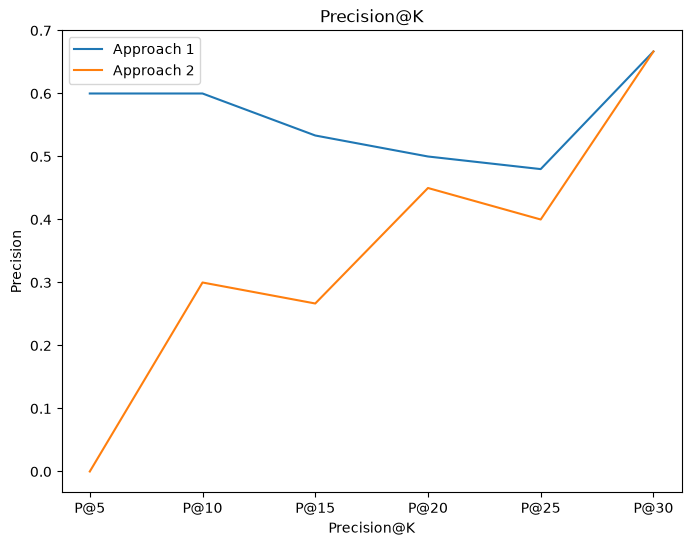

In [101]:
plt.figure(figsize=(8,6))
plt.plot(precision_stage, precision_at_stage_approach1)
plt.plot(precision_stage, precision_at_stage_approach2)
plt.legend(['Approach 1', 'Approach 2'])
plt.xticks(precision_stage, ['P@'+str(pre_stage) for pre_stage in precision_stage])
plt.title('Precision@K')
plt.xlabel('Precision@K')
plt.ylabel('Precision')
plt.show()

###### 3. Mean Average Precision(MAP) for Approach 1 and Approach 2

In [102]:
print('Mean Average Precision(MAP) for Approach 1 is %.2f'%(sum(precision_at_stage_approach1)/len(precision_at_stage_approach1)))
print('Mean Average Precision(MAP) for Approach 2 is %.1f'%(sum(precision_at_stage_approach2)/len(precision_at_stage_approach2)))

Mean Average Precision(MAP) for Approach 1 is 0.56
Mean Average Precision(MAP) for Approach 2 is 0.3
